# Tutorial — PBMC scATAC, start to finish

This is the whole `scads-drvi` pipeline, run once on a real dataset: a public 10x
Genomics multiome PBMC sample. Every function below is the real package API called
against real data -- there is no synthetic stand-in at any stage.

```
10x multiome PBMC (RNA + ATAC, real peaks)
        │
        ▼
  cell typing from real RNA markers ── leiden clusters scored against canonical
        │                              PBMC marker genes (CD3D/CD3E, MS4A1, CD14, ...)
        ▼
  Factorize   (scvi.external.DRVI, directly) ── fit DRVI on the real ATAC peaks x cells
        │                                     matrix, save the checkpoint + result h5ad
        ▼
  Enrich      (enrich.*, pl.enrichment)     ── real per-factor peak→SNP annotations
        │                                     against 1000G, real S-LDSC against
        │                                     Ishigaki et al. 2022 rheumatoid arthritis
        │                                     GWAS, plotted as the heritability landscape
        ▼
  Cell scores (scores.*, pl.*)              ── cs_from_z, per-cell-type summaries,
                                                the ten standard figures throughout
```

Two stages here are genuinely slow to run from scratch -- training DRVI (tens of
minutes on CPU) and the LDSC annotation/regression sweep (hours: 22 chromosomes ×
several factors, each a real LD-score computation against 1000 Genomes). Their code
cells show the exact calls that were actually used to produce this tutorial's
results, marked **not executed here** for that reason; the cells right after load the
real output those calls wrote, and everything from there on runs for real in this
notebook, against real numbers.


## 0. Get the data

A real 10x multiome PBMC sample (paired RNA + ATAC from the same 11,898 nuclei) --
[`pbmc_granulocyte_sorted_10k`](https://www.10xgenomics.com/datasets), Cell Ranger ARC
2.0.0. `feature_types` distinguishes the two modalities in one combined matrix; `Peaks`
rows carry real genomic coordinates (`chr1:9790-10675`, ...) as `var_names` directly --
already the canonical `chr:start-end` form `scads-drvi` expects a peak name in.

This notebook only reads and plots results. Every input it loads -- this download,
the QC/cell-typing below, the DRVI fit, its interpretability scores, and the S-LDSC
sweep against the RA GWAS -- is produced by the Snakemake pipeline in `workflow/`
(a git submodule). Run that first (see `workflow/README.md`); its outputs land under
`workflow/data/` and `workflow/results/`, which is where every cell below reads from.


## 1. Split modalities, call real cell types from real markers

`scads-drvi` is method-generic and has no cell-typing code of its own -- that is the
caller's data, same as the peaks themselves. `workflow/rules/fetch_data.smk`'s
`prepare_atac_rna` rule (`workflow/scripts/prepare_atac_rna.py`) does the standard
scanpy work: normalize, PCA, neighbors, Leiden on the **RNA** modality, then score
each cluster against canonical PBMC marker genes and take the top-scoring cell type
per cluster. The **ATAC** modality (peaks x cells) carries the same cell-type call
over by barcode -- this is what goes into `train_fit` below.


In [1]:
import anndata as ad

rna = ad.read_h5ad("../../workflow/data/pbmc_rna.h5ad")
atac = ad.read_h5ad("../../workflow/data/pbmc_atac.h5ad")
print(f"rna {rna.shape}, atac {atac.shape}")
rna.obs["cell_type"].value_counts()


rna (11566, 21955), atac (11566, 20000)


cell_type
Monocyte    3802
CD4 T       3492
CD8 T       1554
NK          1375
B            920
DC           423
Name: count, dtype: int64

## 2. Factorize: `scvi.external.DRVI`, directly

No wrapper here: `DRVI.setup_anndata`, train, `model.save`, build the embed -- same
calls as [DRVI's own
tutorial](https://drvi.readthedocs.io/latest/tutorials/external/general_pipeline.html).

The GPU refit and embedding extraction are driven by `workflow/` (a Snakemake
pipeline, mounted here as a git submodule of its own dedicated repo -- see
`workflow/README.md`) rather than inline in this cell: training is expensive enough
(a few minutes for 200 epochs over ~11.5k cells x 20k peaks on GPU, much longer on
CPU) and resumable enough that it belongs in a real DAG, not a notebook cell's own
manual `if Path(MODEL_DIR).exists()` check. The whole DAG is self-provisioning --
there's no separate "run this script first" step. Run it once before this cell:

```bash
.venv/bin/python workflow/snakemake_cli.py --use-conda --conda-frontend micromamba \
    --profile workflow/profiles/slurm -j <n>
```

This cell just loads the pipeline's own outputs (`workflow/results/pbmc_model_gpu`,
`workflow/results/pbmc_result_gpu.h5ad`). To keep the rest of this notebook reproducible
against the canonical `workflow/results/pbmc_result.h5ad` -- the fit whose factors
already have a validated, hours-long S-LDSC sweep behind them in
`workflow/results/enrich_results` -- this GPU run's checkpoint and embedding stay under
separate `*_gpu` paths rather than overwriting that canonical output. Section 2's
diagnostics onward keep loading the canonical fit.


In [2]:
from pathlib import Path

import anndata as ad
import scvi
from scvi.external import DRVI

MODEL_DIR = "../../workflow/results/pbmc_model_gpu"
EMBED_PATH = "../../workflow/results/pbmc_result_gpu.h5ad"

if not Path(MODEL_DIR).exists() or not Path(EMBED_PATH).exists():
    raise FileNotFoundError(
        f"{MODEL_DIR} / {EMBED_PATH} not found -- run the pipeline first:\n"
        "  .venv/bin/python workflow/snakemake_cli.py --use-conda "
        "--conda-frontend micromamba --profile workflow/profiles/slurm -j <n>\n"
        "(from the repo root; see workflow/README.md)."
    )

scvi.settings.seed = 0
DRVI.setup_anndata(atac, batch_key=None)
model = DRVI.load(MODEL_DIR, adata=atac)
embed_gpu = ad.read_h5ad(EMBED_PATH)


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seed set to 0


INFO     File ../../workflow/results/pbmc_model_gpu/model.pt already downloaded                                    


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/programs/celltypes/workgroups/hct/mike.cuoco/ ...


INFO     The model has been initialized                                                                            


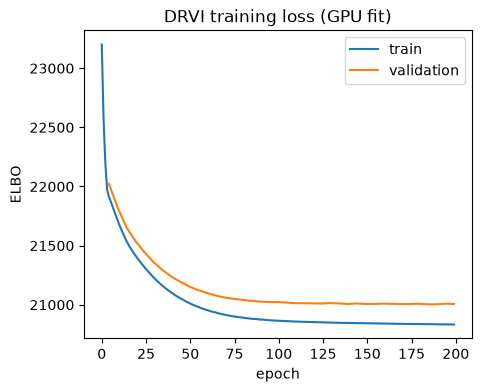

In [3]:
import matplotlib.pyplot as plt

# reconstruction_loss tracks elbo almost exactly here -- KL's contribution to the
# total is small relative to reconstruction -- so just the loss actually being
# optimized (ELBO) is shown, not both.
fig, ax = plt.subplots(figsize=(5, 4))
for split in ("train", "validation"):
    key = f"elbo_{split}"
    if key in model.history:
        # .iloc[:, 0] -- a bare single-column DataFrame ignores plot()'s `label`
        # kwarg and falls back to the column name (e.g. "elbo_train") instead.
        model.history[key].iloc[:, 0].plot(ax=ax, label=split)
ax.set_xlabel("epoch")
ax.set_ylabel("ELBO")
ax.set_title("DRVI training loss (GPU fit)")
ax.legend()
fig;


In [4]:
import anndata as ad

embed = ad.read_h5ad("../../workflow/results/pbmc_result.h5ad")
embed


AnnData object with n_obs × n_vars = 11566 × 32
    obs: 'cell_type', 'n_genes_by_counts', 'total_counts'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished', 'vanished_positive_direction', 'vanished_negative_direction'
    uns: 'cell_type_colors', 'enrich', 'provenance'
    obsm: 'X_umap'
    layers: None (.X)

`embed.var` carries DRVI's own per-dimension statistics
(`model.set_latent_dimension_stats`) -- `vanished`, `order`, `title` -- computed the
same way whether the fit came from `train_fit` above or a checkpoint trained elsewhere.


In [5]:
print(f"{int(embed.var['vanished'].sum())} of {embed.n_vars} dimensions vanished")
embed.var[["vanished", "order"]].sort_values("order").head(10)


0 of 32 dimensions vanished


,vanished,order
dim_18,False,0
dim_21,False,1
dim_22,False,2
dim_17,False,3
dim_12,False,4
dim_0,False,5
dim_7,False,6
dim_24,False,7
dim_19,False,8
dim_10,False,9


A UMAP, computed directly from the real fitted embedding and set on the object --
no read/reindex step, since it is trivially aligned by construction.


In [6]:
import scanpy as sc

# A throwaway copy for the neighbors graph -- only its X_umap coordinates get kept on
# `embed` itself, so the neighbors graph never leaks into the canonical result h5ad
# written back to disk in Section 3.
_tmp = embed.copy()
sc.pp.neighbors(_tmp, n_neighbors=15)
sc.tl.umap(_tmp, min_dist=0.3, spread=1.0)
embed.obsm["X_umap"] = _tmp.obsm["X_umap"]
del _tmp


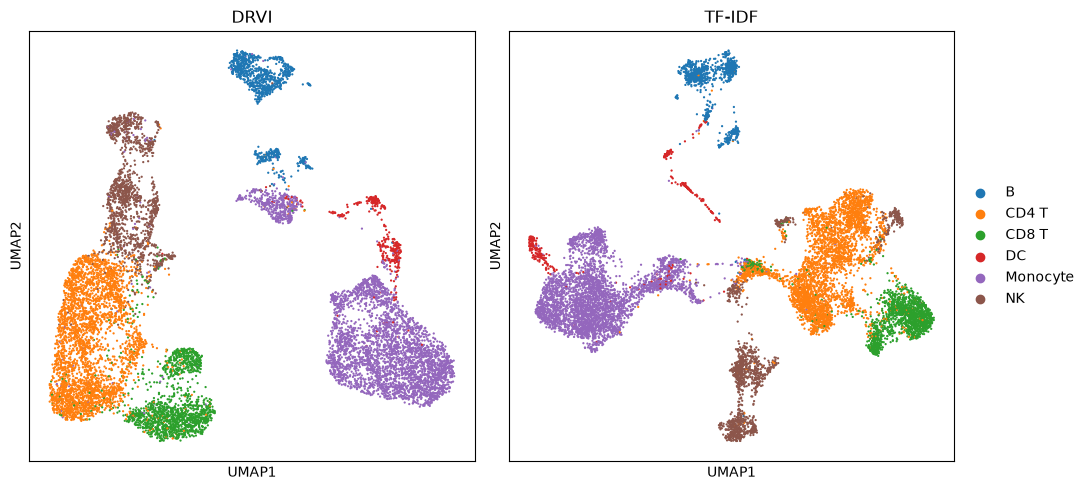

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

cells = embed.obs.copy()


def tfidf(X):
    """Log(TF)-log(IDF) -- Signac's default, same as muon.atac.pp.tfidf's defaults."""
    tf = X.multiply(1 / X.sum(axis=1)).tocsr()
    tf.data = np.log1p(tf.data * 1e4)
    idf = np.log1p(np.asarray(X.shape[0] / X.sum(axis=0))).ravel()
    return tf.multiply(idf).tocsr()


# The standard scATAC linear baseline -- TF-IDF, then PCA/SVD directly on the
# resulting sparse matrix with no mean-centering (i.e. LSI) -- on the exact same
# peaks x cells matrix DRVI was trained on. One extra component is computed
# (n_comps=33) so the first can be dropped before neighbors/UMAP -- it routinely just
# tracks sequencing depth rather than biology (the same reason Signac/ArchR drop it by
# default) -- leaving 32 components, DRVI's own n_latent.
atac_tfidf = atac.copy()
atac_tfidf.X = tfidf(atac_tfidf.X)
sc.pp.pca(atac_tfidf, n_comps=33, zero_center=False)
atac_tfidf.obsm["X_pca"] = atac_tfidf.obsm["X_pca"][:, 1:]
sc.pp.neighbors(atac_tfidf, n_neighbors=15)
sc.tl.umap(atac_tfidf, min_dist=0.3, spread=1.0)

# One shared cell_type legend -- both panels share the same categories/colors, so the
# left panel's would-be copy is dropped rather than shown twice.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sc.pl.embedding(
    embed, basis="umap", color="cell_type", ax=axes[0], show=False, title="DRVI",
    legend_loc=None,
)
sc.pl.embedding(
    atac_tfidf, basis="umap", color="cell_type", ax=axes[1], show=False, title="TF-IDF",
)
fig.tight_layout()
fig;

Every dimension `scads-drvi` keeps gets its own diagnostics -- how it correlates with its neighbours, whether it tracks a nuisance covariate, its own summary statistics, what it looks like spatially, and how its value varies across cell types. All of `pl.umap`/`pl.factors`'s figures are in-house (wrapping `scanpy.pl.embedding` where an embedding is involved), so none of this needs a `drvi-py` install:

In [8]:
embed.obs

,cell_type,n_genes_by_counts,total_counts
AAACAGCCAAGGAATC-1,CD4 T,16515,60810.0
AAACAGCCAATCCCTT-1,CD4 T,8885,23781.0
AAACAGCCAATGCGCT-1,CD4 T,8168,19975.0
AAACAGCCACACTAAT-1,CD8 T,651,1437.0
AAACAGCCACCAACCG-1,CD8 T,4227,9289.0
...,...,...,...
TTTGTTGGTGACATGC-1,CD8 T,7114,18812.0
TTTGTTGGTGTTAAAC-1,CD8 T,8023,19768.0
TTTGTTGGTTAGGATT-1,NK,5475,12537.0
TTTGTTGGTTGGTTAG-1,CD4 T,7993,20626.0


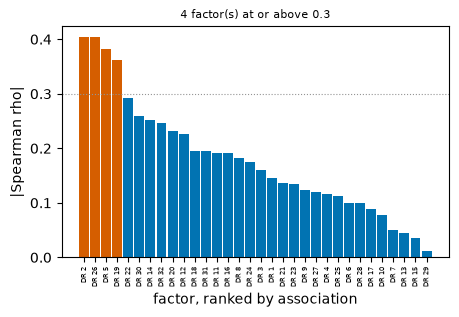

In [9]:
import pandas as pd
from scipy.stats import spearmanr

from scads_drvi.pl.factors import covariate_association

# Does any factor just track sequencing depth rather than biology? Labeled by DRVI's
# own "DR N" title, not the raw dim_N index -- see factor_correlation below.
covariate = embed.obs["n_genes_by_counts"].to_numpy(dtype=float)
rho = pd.Series(
    [spearmanr(embed.X[:, j], covariate).statistic for j in range(embed.n_vars)],
    index=embed.var["title"],
)
fig, _ = covariate_association(rho, threshold=0.3)
fig;

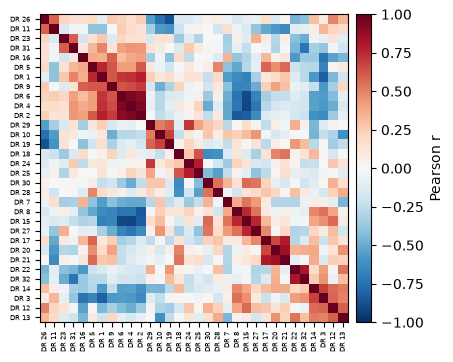

In [10]:
import pandas as pd

from scads_drvi.pl.factors import factor_correlation

# Labeled by DRVI's own "DR N" title, not the raw dim_N index -- the same convention
# latent_umap_grid/latent_heatmap already display factors under.
signed_loadings = pd.DataFrame(embed.X, index=embed.obs_names, columns=embed.var["title"])
vanished_titles = embed.var.loc[embed.var["vanished"], "title"]

fig, _ = factor_correlation(signed_loadings.corr(), vanished=vanished_titles)
fig;

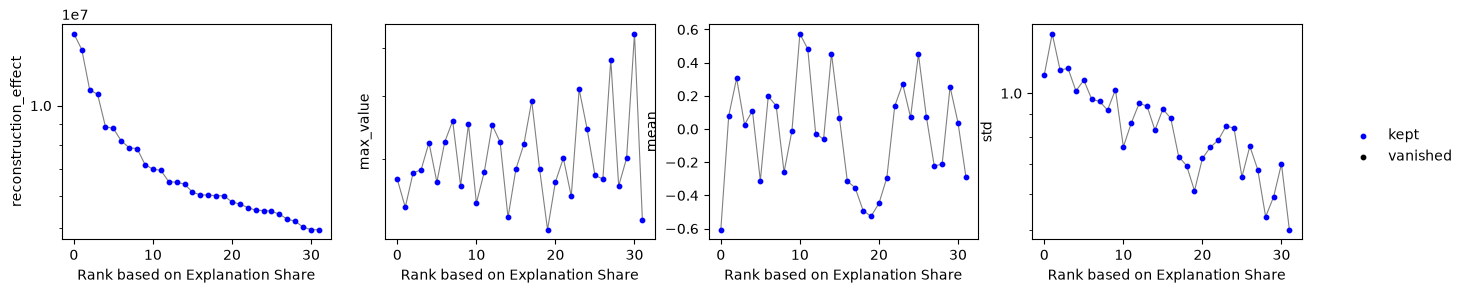

In [11]:
from scads_drvi.pl.factors import latent_dimension_stats

fig, _ = latent_dimension_stats(embed.var)
fig;

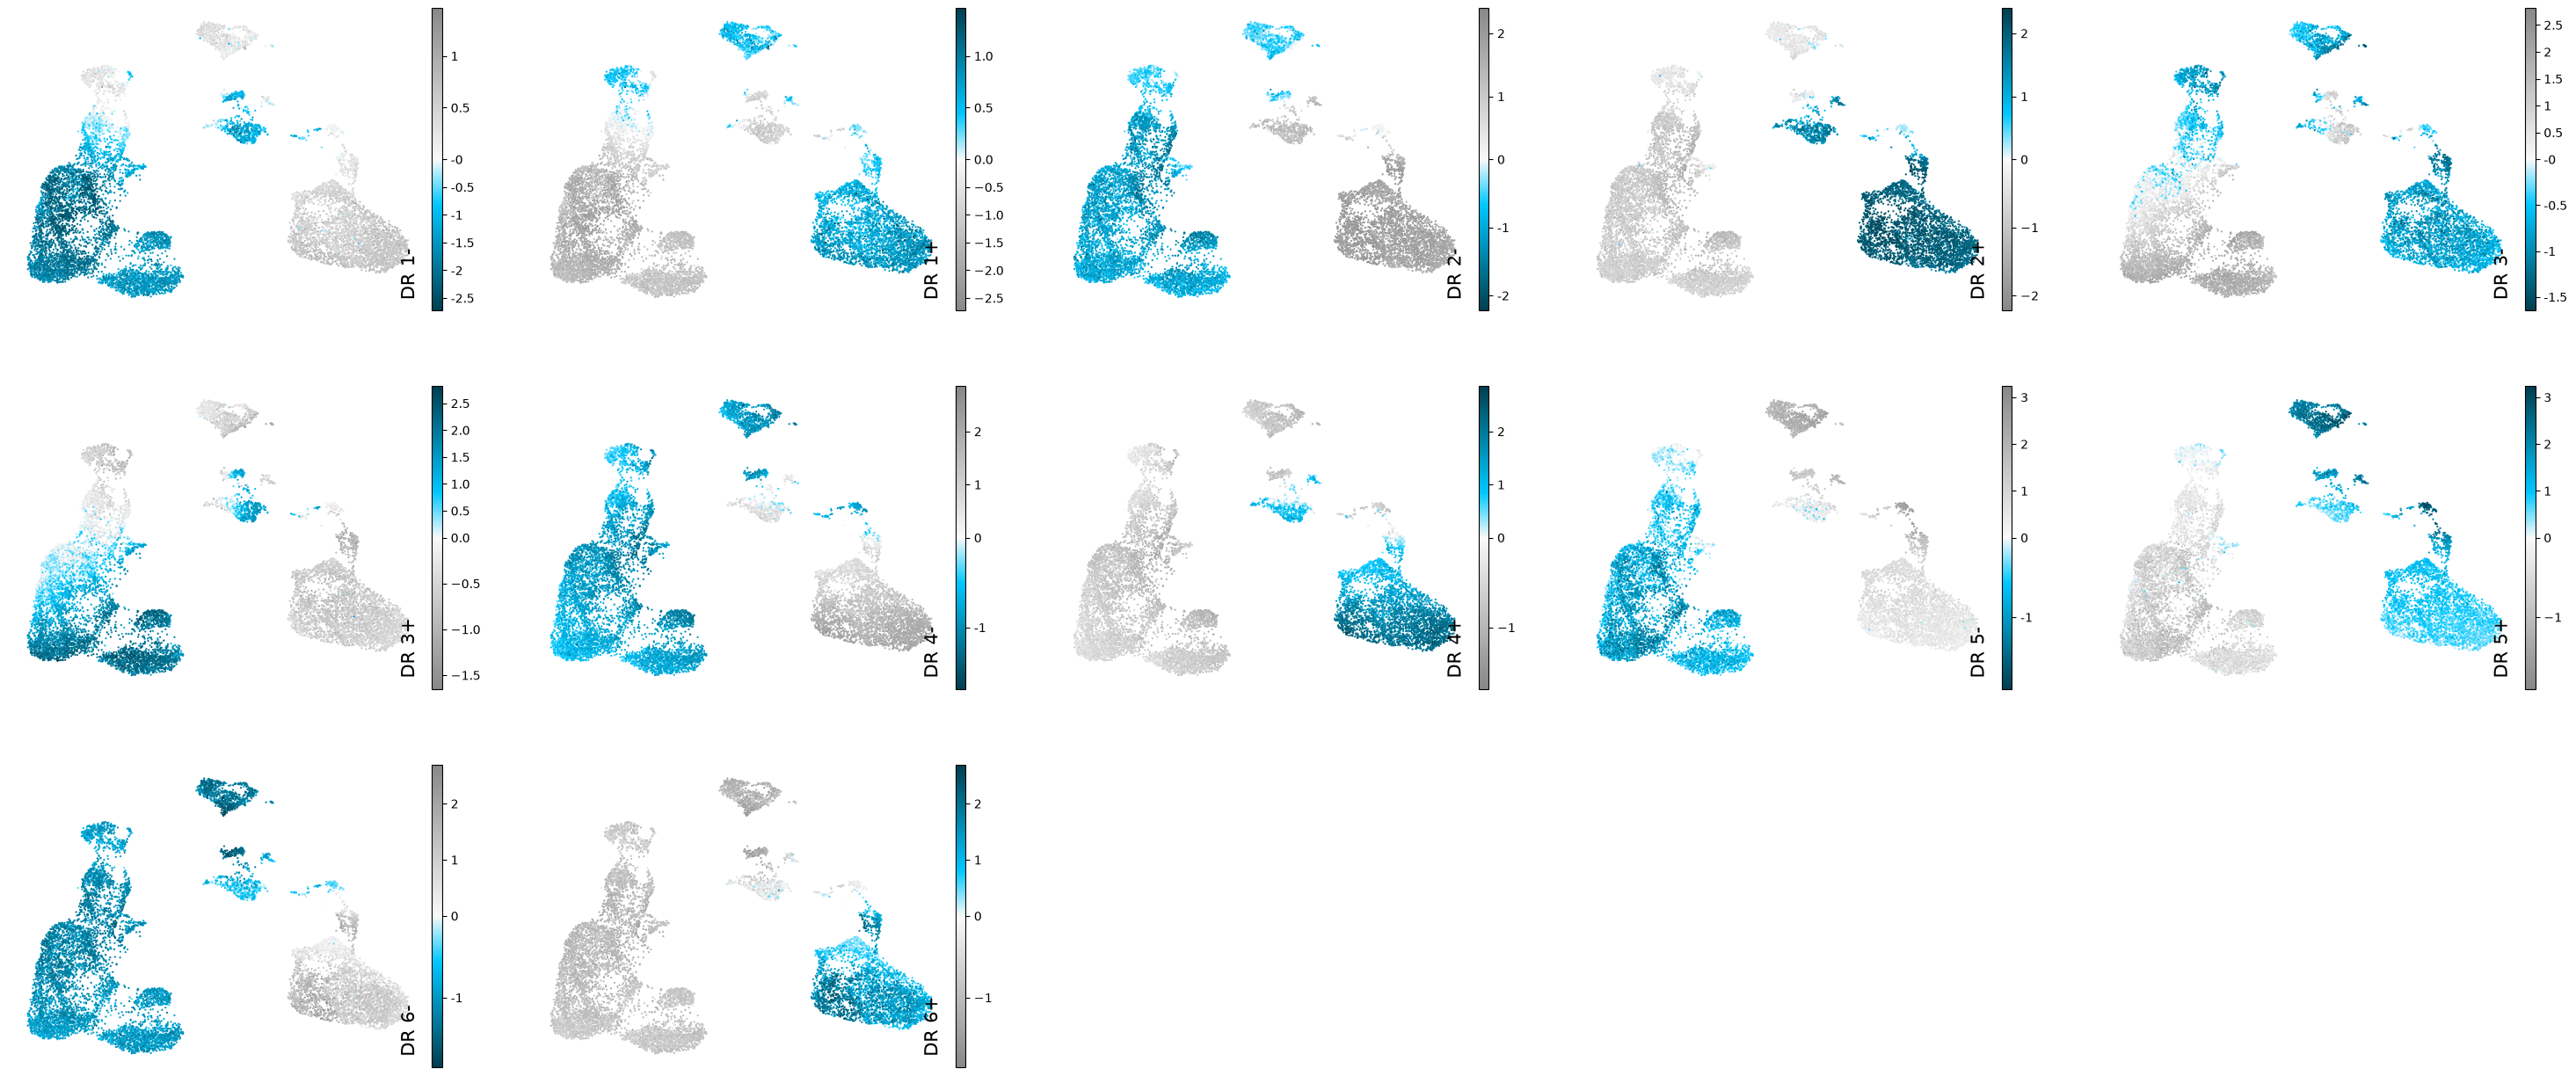

In [12]:
from scads_drvi.pl.umap import latent_umap_grid

# A compact subset for a readable grid -- the first six by DRVI's own rank.
# directional=True is the default -- each dimension gets its own +/- panel pair (12
# panels total for six dims), not just one panel per dimension.
first_six = list(embed.var.sort_values("order").index[:6])
fig = latent_umap_grid(embed, dim_subset=first_six)
fig;

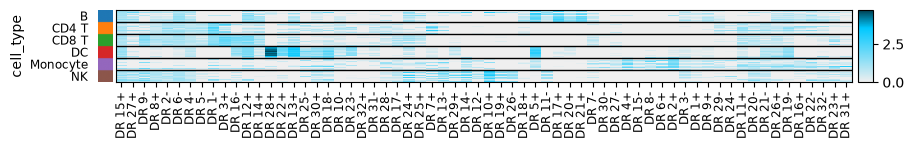

In [13]:
from scads_drvi.pl.factors import latent_heatmap

# order="cluster" here (vs. the default "rank") -- grouped by which cells drive
# similar factors, not by DRVI's explained-share ranking. directional=True is also
# the default (unset here): every kept dimension becomes two columns, its own ReLU'd
# positive and negative parts, not one.
fig, _ = latent_heatmap(embed, "cell_type", order="cluster")
fig;

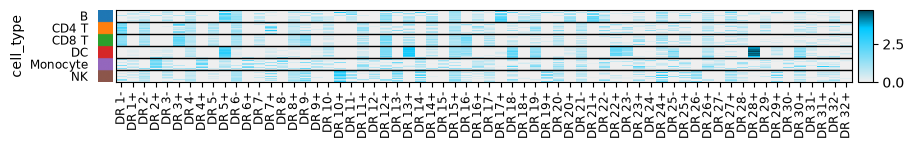

In [14]:
# The default order="rank" instead -- DRVI's own explained-share ranking, not the
# correlation-driven grouping above. directional=True (also the default, unset here)
# still splits every dimension into its own +/- columns either way.
fig, _ = latent_heatmap(embed, "cell_type")
fig;

## 3. Enrich: real peaks → real S-LDSC against a real rheumatoid arthritis GWAS

`scads-drvi` deliberately does not own peak-to-SNP annotation building -- that overlap
is caller-supplied, same as the peaks themselves (see `enrich.config`'s module
docstring). RA is a genuinely well-powered choice for a PBMC (peripheral immune cell) fit: its genetic architecture is one of the most consistently replicated immune/T-cell heritability enrichments in the S-LDSC literature, unlike Alzheimer's disease (tried first here), whose risk concentrates in brain microglia rather than peripheral blood monocytes -- a real reason peripheral PBMC factors showed no significant enrichment for it.

The annotation builder: for each kept factor, DRVI's own
`get_effect_of_splits_within_distribution(..., aggregations="exp_weighted_mean",
directional=True)` splits that factor's peak effects into its **positive and negative
directions separately** (index 0 is positive, index 1 negative -- two distinct
biological programs a single signed factor can carry), each aggregated across cells
as an expectation weighted by `exp(latent value)` -- a smoother, population-level
effect size than one cell's maximum. Each peak's own **continuous, non-negative**
value (not a binary top-`k%` mask) becomes the per-SNP annotation directly, matching
this package's own documented default (`README.md`'s "Enrich (S-LDSC)" section) --
every SNP inside a peak gets that peak's exact loading, every SNP outside every peak
gets `0.0` -- against the real baseline-LD v2.2 reference and
[Ishigaki et al. 2022](https://doi.org/10.1038/s41588-022-01213-w)'s rheumatoid
arthritis (RA) GWAS summary statistics (97,173 European-ancestry samples) --
**for both directions of every factor**, so a factor whose positive and negative
loadings mark different peak sets gets tested twice, once per direction.

This sweeps 22 chromosomes x several factors x 2 directions of real LD-score
computation -- tens of minutes to a couple of hours, not seconds -- so, same as
Section 2's fit, it's driven by `workflow/` (see `workflow/README.md`) rather than
inline here: one batched `ldsc l2` call per chromosome across every kept
factor/direction at once, then one `ldsc h2` per factor/direction against the
real baseline-LD v2.2 reference `rules/fetch_data.smk` provisions into
`workflow/data/ldsc_reference/`. Run it once before this cell (same command as
Section 2 -- one pipeline covers both stages):

```bash
.venv/bin/python workflow/snakemake_cli.py --use-conda --conda-frontend micromamba \
    --profile workflow/profiles/slurm -j <n>
```

This cell just loads the pipeline's own tidy results parquet and rebuilds `loadings`
(cheap -- a single forward pass through the already-fitted `model`, needed by
Section 3b's peak-risk decomposition below) directly from `model`/`atac`, the same way
the pipeline's own `ldscore_chrom` rule does.

**Alternative: UK Biobank in-sample LD instead of 1000G.** `scads-drvi` doesn't manage
reference panels itself -- any `--ref-ld-chr` stem is just a path you supply. For a GWAS
run on UK Biobank itself (in-sample LD is preferred there over an external 1000G panel),
the Alkes-group baseline-LF v2.2 UKB reference is a plain download, not a package
dependency:

```bash
wget https://broad-alkesgroup-ukbb-ld.s3.amazonaws.com/UKBB_LD/baselineLF_v2.2.UKB.tar.gz
tar xzf baselineLF_v2.2.UKB.tar.gz
```

Two things about the extracted layout are easy to get wrong and silent when wrong,
confirmed against a real download rather than guessed: it extracts to
`baselineLF_v2.2.UKB/`, but the per-chromosome file prefix **inside** it drops the
underscore -- files are `baselineLF_v2.2.UKB/baselineLF2.2.UKB.{chrom}.annot.gz` /
`.l2.ldscore.gz` / `.l2.M` / `.l2.M_5_50`, so the `ref_ld_chr` stem to pass is
`.../baselineLF_v2.2.UKB/baselineLF2.2.UKB.`, not `baselineLF_v2.2.UKB.`. The archive
is ~11 GB; point the download at scratch storage, not a small home directory.


In [15]:
from pathlib import Path

import pandas as pd

from scads_drvi.enrich.config import kept_dims, select_factors

TRAIT = "ra_ishigaki2022_eur"
METRIC = "IND_exp_weighted_mean"  # which interpretability score the sweep annotated with
RESULTS_DIR = Path("../../workflow/results/enrich_results_gpu") / METRIC
SCORES_PATH = Path("../../workflow/results/enrich_work_gpu/ind_interpretability_scores.h5ad")

results = pd.read_parquet(RESULTS_DIR / f"{TRAIT}.results_tidy.parquet")

fmap = select_factors(embed_gpu.var, list(embed_gpu.var_names))
keep = kept_dims(fmap)   # dims that survive vanished-filtering

# The pipeline's own per-peak scores, saved as varm[METRIC] with shape
# (n_factors, 2, n_peaks): axis 1 is direction (0 positive, 1 negative). These are
# the exact values the sweep's annotations were built from, so Section 3b's
# decomposition matches the fitted tau. Peak order is the ATAC matrix's own.
scores = ad.read_h5ad(SCORES_PATH).varm[METRIC]
loadings = {
    direction: pd.DataFrame(
        scores[:, d, :].T, index=atac.var_names, columns=embed_gpu.var_names
    )[keep]
    for d, direction in enumerate(("pos", "neg"))
}


In [16]:
# Attaching an enrichment arm is a plain dict assignment into uns["enrich"][model] --
# no wrapper for it either. `results` is already read_results()'s own output (see the
# cell above); annot_index is dropped from factor_selection: it is a purely internal
# detail of how annotation files were named for the LDSC calls, never a public record.
embed_gpu.uns.setdefault("enrich", {})["ra_ishigaki2022_eur"] = {
    "results": results,
    "factor_selection": fmap.drop(columns="annot_index"),
}

results.sort_values("Coefficient_z-score", ascending=False).head(10)


,Category,Prop._SNPs,Prop._h2,Prop._h2_std_error,Enrichment,Enrichment_std_error,Enrichment_p,Coefficient,Coefficient_std_error,Coefficient_z-score,trait,annot,dim,direction,p_1tailed,fdr_q
1,dr_0_negL2_0,0.000857,0.056101,0.011865,65.450685,13.842421,0.000007,0.000005,1.474862e-06,3.597604,ra_ishigaki2022_eur,dr_0_neg,dr_0,neg,0.000161,0.010060
12,dr_6_posL2_0,0.000351,0.021403,0.004762,60.922994,13.555514,0.000019,0.000012,3.528064e-06,3.317151,ra_ishigaki2022_eur,dr_6_pos,dr_6,pos,0.000455,0.010060
28,dr_14_posL2_0,0.000434,0.027631,0.006577,63.644870,15.149537,0.000043,0.000010,2.972524e-06,3.287629,ra_ishigaki2022_eur,dr_14_pos,dr_14,pos,0.000505,0.010060
44,dr_22_posL2_0,0.001404,0.064364,0.013971,45.855389,9.953747,0.000008,0.000002,7.776564e-07,3.211865,ra_ishigaki2022_eur,dr_22_pos,dr_22,pos,0.000659,0.010060
31,dr_15_negL2_0,0.000631,0.032143,0.007771,50.943223,12.316190,0.000040,0.000004,1.402554e-06,3.134566,ra_ishigaki2022_eur,dr_15_neg,dr_15,neg,0.000861,0.010060
9,dr_4_negL2_0,0.002125,0.126702,0.030759,59.620146,14.474023,0.000066,0.000002,5.578774e-07,3.093466,ra_ishigaki2022_eur,dr_4_neg,dr_4,neg,0.000989,0.010060
37,dr_18_negL2_0,0.001369,0.076232,0.018439,55.675475,13.466763,0.000060,0.000002,7.231337e-07,3.061734,ra_ishigaki2022_eur,dr_18_neg,dr_18,neg,0.001100,0.010060
7,dr_3_negL2_0,0.000179,0.006871,0.001587,38.343745,8.859009,0.000014,0.000017,5.985065e-06,2.810664,ra_ishigaki2022_eur,dr_3_neg,dr_3,neg,0.002472,0.019776
54,dr_27_posL2_0,0.000323,0.019345,0.005423,59.804882,16.766316,0.000419,0.000012,4.496502e-06,2.724342,ra_ishigaki2022_eur,dr_27_pos,dr_27,pos,0.003221,0.022908
5,dr_2_negL2_0,0.000179,0.006916,0.001654,38.713917,9.255356,0.000036,0.000021,8.142976e-06,2.532564,ra_ishigaki2022_eur,dr_2_neg,dr_2,neg,0.005662,0.035995


`q < 0.05` marks factors whose peaks are significantly enriched for rheumatoid
arthritis heritability, Benjamini–Hochberg corrected across every factor tested.


In [17]:
from scads_drvi.stats import significant

arm = embed_gpu.uns["enrich"]["ra_ishigaki2022_eur"]["results"]
print(f"{int(significant(arm).sum())} of {len(arm)} factor-directions significant at q < 0.05")
arm.loc[significant(arm)].sort_values("fdr_q")


14 of 64 factor-directions significant at q < 0.05


,Category,Prop._SNPs,Prop._h2,Prop._h2_std_error,Enrichment,Enrichment_std_error,Enrichment_p,Coefficient,Coefficient_std_error,Coefficient_z-score,trait,annot,dim,direction,p_1tailed,fdr_q
1,dr_0_negL2_0,0.000857,0.056101,0.011865,65.450685,13.842421,0.000007,0.000005,1.474862e-06,3.597604,ra_ishigaki2022_eur,dr_0_neg,dr_0,neg,0.000161,0.010060
9,dr_4_negL2_0,0.002125,0.126702,0.030759,59.620146,14.474023,0.000066,0.000002,5.578774e-07,3.093466,ra_ishigaki2022_eur,dr_4_neg,dr_4,neg,0.000989,0.010060
12,dr_6_posL2_0,0.000351,0.021403,0.004762,60.922994,13.555514,0.000019,0.000012,3.528064e-06,3.317151,ra_ishigaki2022_eur,dr_6_pos,dr_6,pos,0.000455,0.010060
28,dr_14_posL2_0,0.000434,0.027631,0.006577,63.644870,15.149537,0.000043,0.000010,2.972524e-06,3.287629,ra_ishigaki2022_eur,dr_14_pos,dr_14,pos,0.000505,0.010060
44,dr_22_posL2_0,0.001404,0.064364,0.013971,45.855389,9.953747,0.000008,0.000002,7.776564e-07,3.211865,ra_ishigaki2022_eur,dr_22_pos,dr_22,pos,0.000659,0.010060
37,dr_18_negL2_0,0.001369,0.076232,0.018439,55.675475,13.466763,0.000060,0.000002,7.231337e-07,3.061734,ra_ishigaki2022_eur,dr_18_neg,dr_18,neg,0.001100,0.010060
31,dr_15_negL2_0,0.000631,0.032143,0.007771,50.943223,12.316190,0.000040,0.000004,1.402554e-06,3.134566,ra_ishigaki2022_eur,dr_15_neg,dr_15,neg,0.000861,0.010060
7,dr_3_negL2_0,0.000179,0.006871,0.001587,38.343745,8.859009,0.000014,0.000017,5.985065e-06,2.810664,ra_ishigaki2022_eur,dr_3_neg,dr_3,neg,0.002472,0.019776
54,dr_27_posL2_0,0.000323,0.019345,0.005423,59.804882,16.766316,0.000419,0.000012,4.496502e-06,2.724342,ra_ishigaki2022_eur,dr_27_pos,dr_27,pos,0.003221,0.022908
26,dr_13_posL2_0,0.000896,0.034848,0.008587,38.899407,9.585095,0.000110,0.000003,1.037733e-06,2.470354,ra_ishigaki2022_eur,dr_13_pos,dr_13,pos,0.006749,0.035995


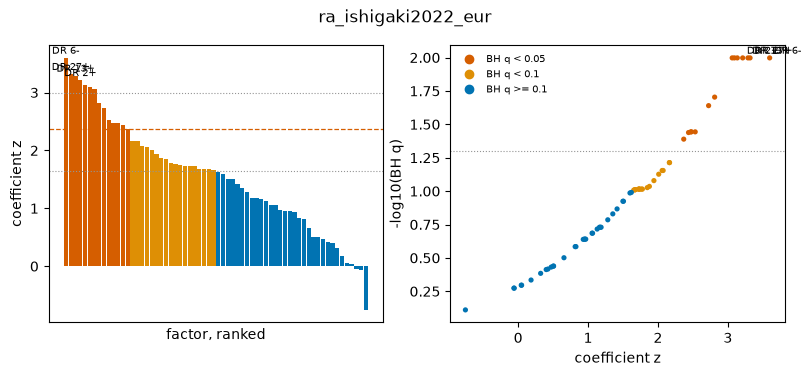

In [18]:
from scads_drvi.pl.enrichment import heritability_landscape

fig, _ = heritability_landscape(arm, trait="ra_ishigaki2022_eur", titles=embed_gpu.var["title"])
fig;

Both panels above rank the same factors, though -- the volcano's `-log10(q)` is a monotone, one-tailed function of the same z-score the bar chart already plots, so on a single trait the two panels are redundant. `latent_heatmap` below pairs that same heritability signal (an optional bar above the heatmap, with its own error bars and BH-significance colouring) with a genuinely different view instead -- which cells actually drive each enriched factor, split into its positive and negative direction by default (`directional=True`, matching `latent_umap_grid`'s own default -- every factor interpretability plot in this package shows split factors unless told not to) -- both directions' real S-LDSC z-scores are shown, not just the one this fit's top peaks happened to be scored under.

(`trait_concordance`, which compares this ranking against a second, independently-run trait, is deliberately not shown with real data here -- this tutorial runs one real S-LDSC sweep, against rheumatoid arthritis; a second real trait means a second multi-hour LDSC run. See its docstring/tests for a worked example.)

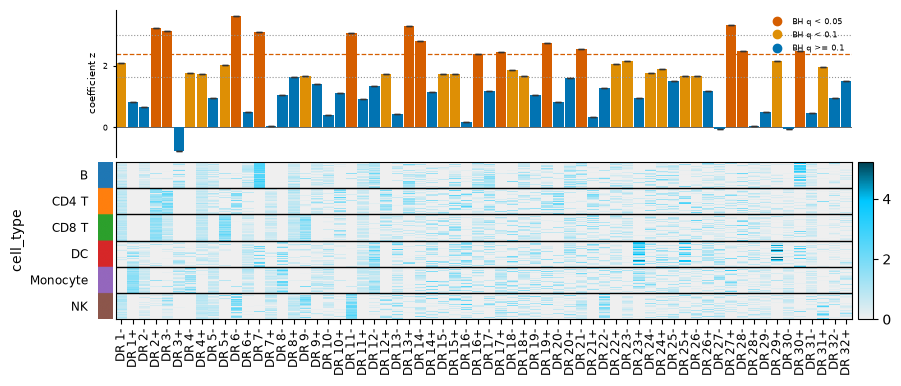

In [19]:
from scads_drvi.pl.factors import latent_heatmap

# Every dim x direction pair S-LDSC actually tested -- both directions now, keyed
# "{dim}+"/"{dim}-" the same way latent_heatmap's own directional split (the default,
# matching latent_umap_grid's own) names its columns, rather than picking one
# direction in advance the way a single-column-per-factor heatmap would have to.
signed = arm.assign(signed_dim=arm["dim"] + arm["direction"].map({"pos": "+", "neg": "-"}))
signed = signed.set_index("signed_dim")
embed_scored = embed_gpu[:, arm["dim"].unique()]

fig, _ = latent_heatmap(
    embed_scored, "cell_type",
    heritability=signed["Coefficient_z-score"], heritability_se=signed["Coefficient_std_error"],
    heritability_q=signed["fdr_q"],
)
fig;

### 3b. How much RA heritability is in each peak?

`heritability_landscape` above answers one question about the *whole* genome: does a
factor's peak set, in aggregate, carry more RA heritability than baseline. It says
nothing about *where* in the genome that heritability actually concentrates.
`enrich.risk` pushes the same fitted S-LDSC coefficient (`tau`, this section's own
`Coefficient` column) back down to individual peaks: since the annotation above is
built peak-by-peak (every SNP's value comes from whichever peak it falls in), a
category's total heritability is exactly additive over peaks --
`tau * loading_peak * n_snps_in_peak` is that peak's own share. No new regression is
fit here; this is the same real sweep above, decomposed to peak resolution.


In [20]:
from scads_drvi.enrich.annotations import read_bim
from scads_drvi.enrich.risk import peak_risk, peak_snp_counts, top_risk_peaks

LDSC_REF = "../../workflow/data/ldsc_reference/grch38_baselineLD_v2.2"
PLINK_PREF = f"{LDSC_REF}/plink_files/1000G.EUR.hg38."
CHROMS = range(1, 23)

# Same per-chromosome .bim files the l2 sweep above already reads, concatenated once
# genome-wide -- peak_snp_counts only needs each peak's overlapping-SNP count, not the
# per-chromosome loop structure the annotation builder needed.
bim_genome = pd.concat(
    [read_bim(f"{PLINK_PREF}{chrom}.bim") for chrom in CHROMS], ignore_index=True
)
snp_counts = peak_snp_counts(atac.var_names, bim_genome)

# `loadings` and `results` are exactly this section's own real sweep output above --
# no new S-LDSC computation, just redistributing the already-fitted tau.
risk = peak_risk(loadings, results, snp_counts=snp_counts)
top_risk_peaks(risk, n=20)


,peak,chrom,start,end,dim,direction,loading,tau,risk_rate,risk_total
0,chr17:22520954-22521851,chr17,22520954,22521851,dr_3,neg,0.227856,0.000017,0.000004,0.000299
1,chr6:32636866-32637776,chr6,32636866,32637776,dr_20,neg,0.638666,0.000010,0.000006,0.000296
2,chr6:32668045-32668962,chr6,32668045,32668962,dr_0,neg,0.647638,0.000005,0.000003,0.000261
3,chr6:32609579-32610490,chr6,32609579,32610490,dr_27,pos,0.323661,0.000012,0.000004,0.000226
4,chr17:22520954-22521851,chr17,22520954,22521851,dr_8,pos,0.318540,0.000008,0.000003,0.000201
5,chr17:22520954-22521851,chr17,22520954,22521851,dr_4,neg,1.441067,0.000002,0.000002,0.000194
6,chr6:32668045-32668962,chr6,32668045,32668962,dr_4,neg,1.450818,0.000002,0.000003,0.000190
7,chr17:22520954-22521851,chr17,22520954,22521851,dr_6,pos,0.206413,0.000012,0.000002,0.000188
8,chr6:32636866-32637776,chr6,32636866,32637776,dr_0,neg,0.702270,0.000005,0.000004,0.000179
9,chr6:32636866-32637776,chr6,32636866,32637776,dr_4,neg,2.082955,0.000002,0.000004,0.000173


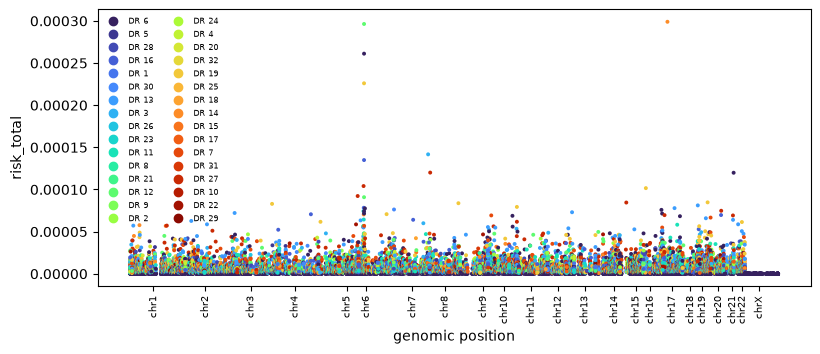

In [21]:
from scads_drvi.pl.enrichment import risk_manhattan

fig, _ = risk_manhattan(risk, titles=embed_gpu.var["title"])
fig;


### 3c. One Manhattan plot per significant factor, with gene labels

The combined view above puts every kept factor on one axis; picking out any single
factor's own genome-wide shape means filtering by eye. This renders one real
[`qmplot`](https://github.com/GATB/qmplot) Manhattan plot per **FDR-significant**
`(dim, direction)` key only (`results["fdr_q"] < 0.05` -- multiplicity-corrected, not
the raw per-key p-value), each labeled with the nearest gene (UCSC's real hg38
`refGene` table, fetched directly over HTTP in the next
cell) at that factor's own top peaks -- not the plot's
global top peaks, since a factor with a modest peak-risk ceiling can still have a
real, distinct genome-wide shape worth seeing on its own axis.

`qmplot.manhattanplot` expects a p-value column and log-transforms it by default
(`logp=True`); `logp=False` here plots `risk_total` directly -- the same "raw score,
not a p-value" case its own docstring documents (peak heights, Bayes factors, and
similar genome-wide scores). It also keeps the *raw row order* of its own chromosome
column rather than sorting it (`groupby(..., sort=False)`), so the numeric 1..22, X
order has to be established on this side first, not left to the package.


14 of 64 keys significant at FDR q<0.05


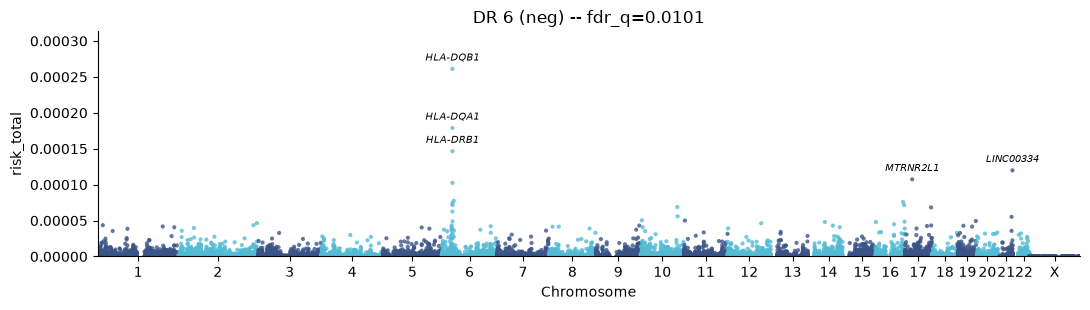

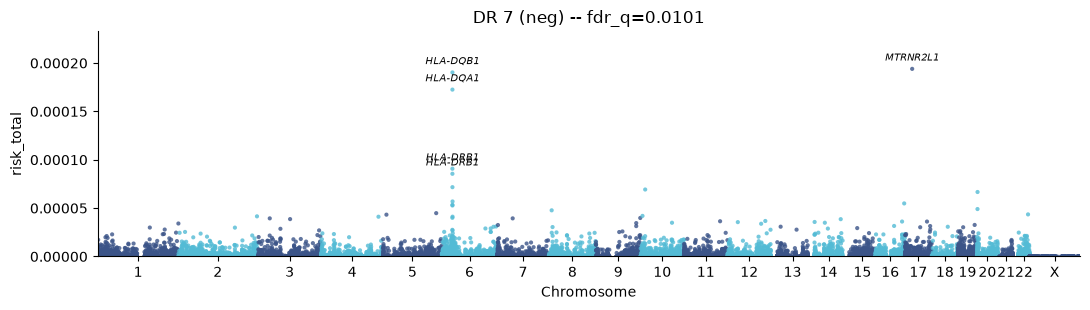

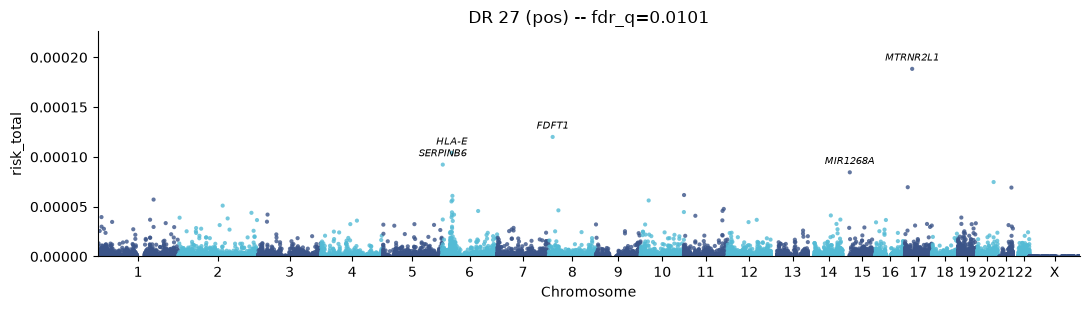

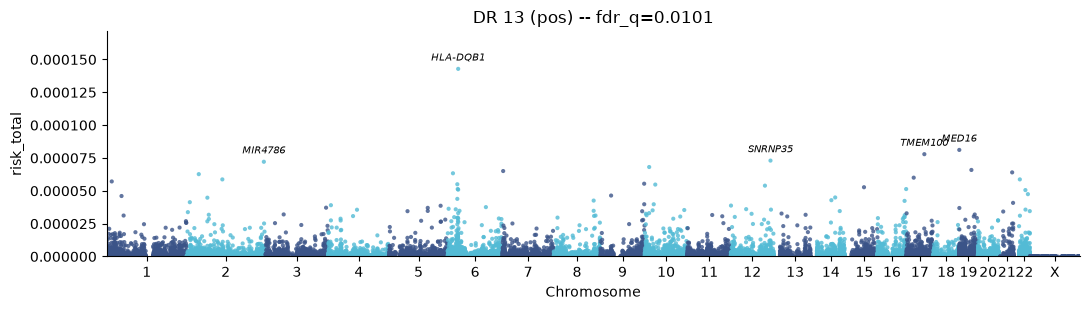

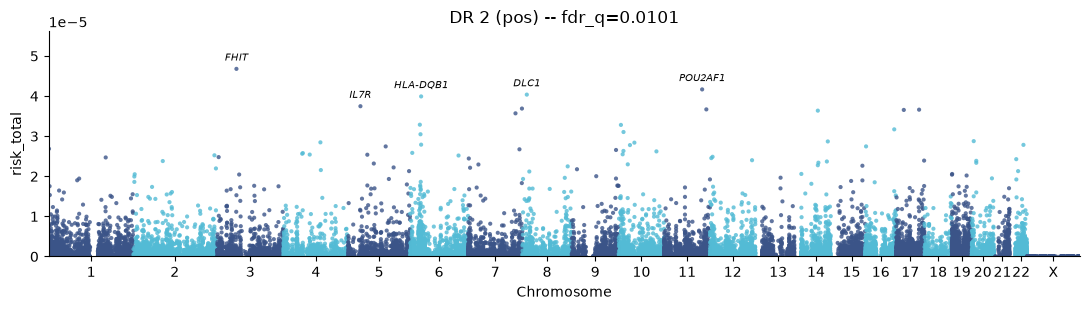

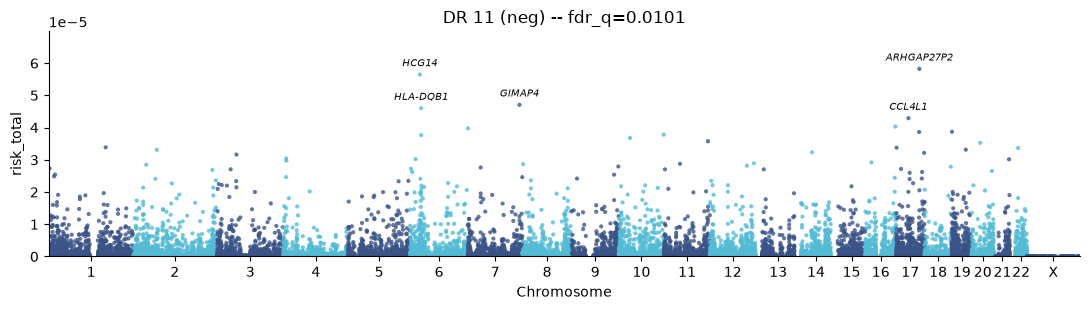

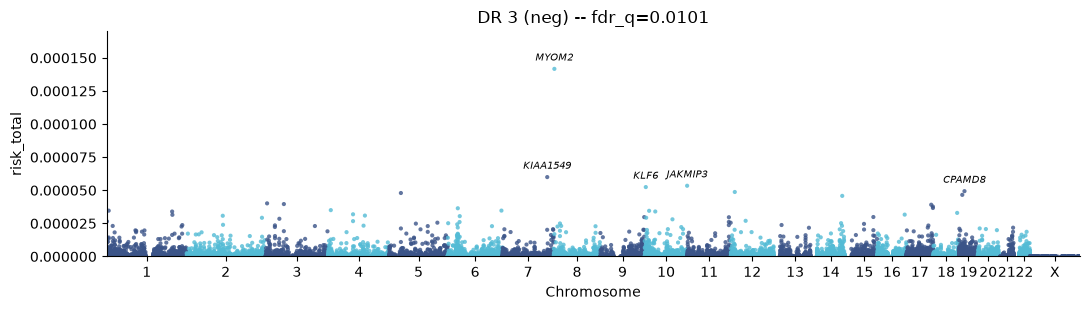

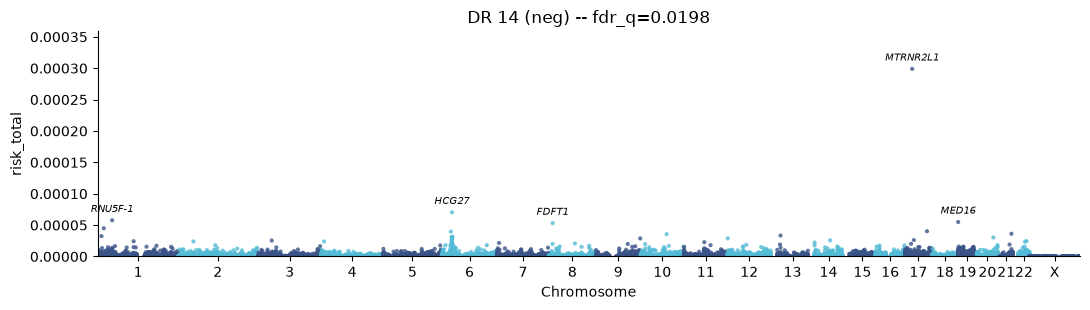

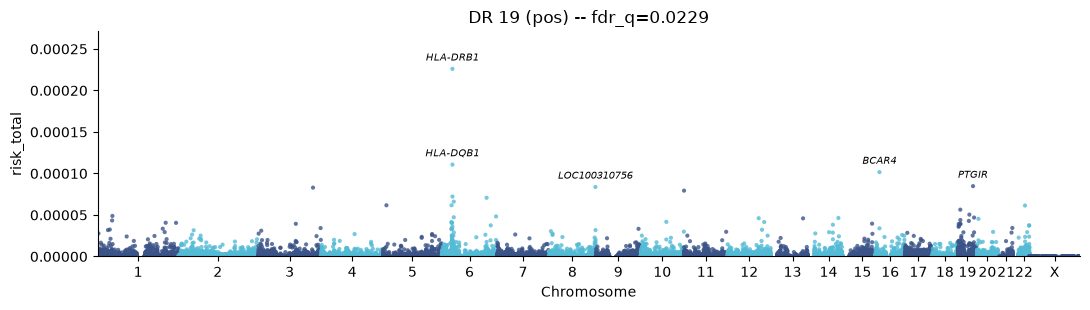

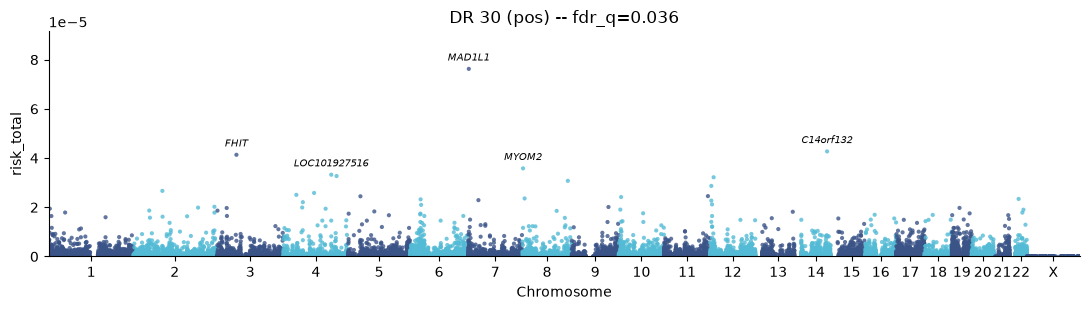

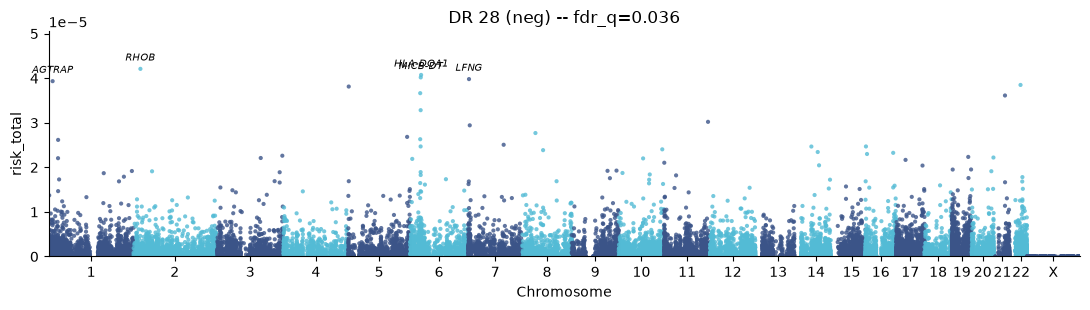

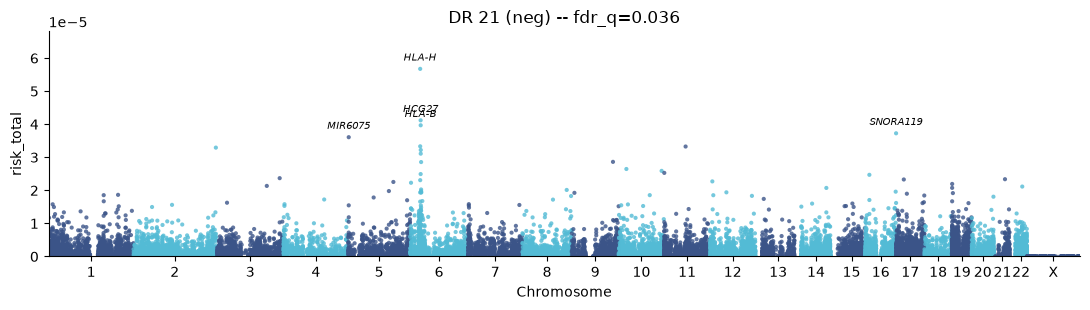

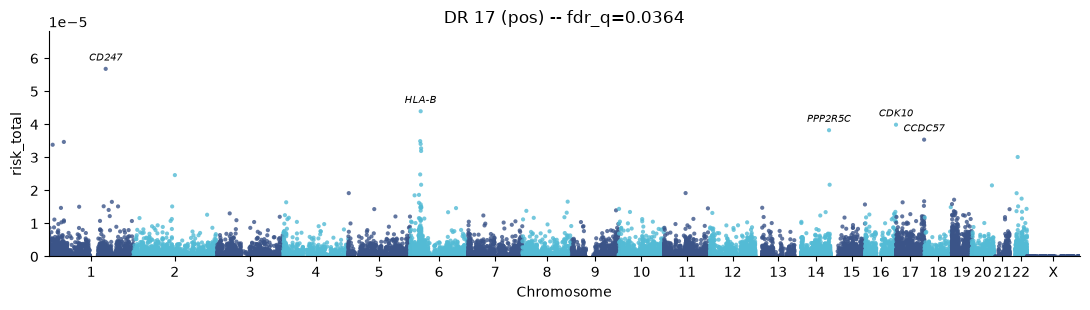

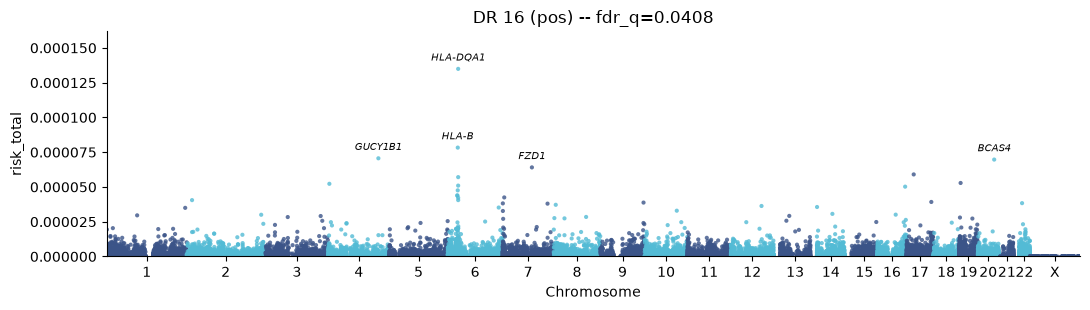

In [22]:
import qmplot
from IPython.display import display

GENE_REF_URL = "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/database/refGene.txt.gz"
N_LABEL = 5  # top peaks labeled per factor, not per plot -- see markdown above

# Not provisioned by workflow/rules/fetch_data.smk -- pandas reads a gzipped TSV
# straight off HTTP just as well as off a local path, so there's no download step
# to run first.
genes = pd.read_csv(
    GENE_REF_URL, sep="\t", header=None, usecols=[2, 4, 5, 12],
    names=["chrom", "start", "end", "gene"],
)
# refGene carries chrM/scaffolds/alt haplotypes too; peaks are only ever on the
# primary autosomes + X (see rules/fetch_data.smk's own PEAK_RE).
genes = genes[genes["chrom"].str.match(r"^chr([0-9]+|X|Y)$")].copy()
genes["chrom_bare"] = genes["chrom"].str.replace(r"(?i)^chr", "", regex=True)


def nearest_gene(chrom: str, pos: int) -> str:
    """The refGene transcript whose own midpoint is closest to `pos` -- simple and
    good enough for a top-peaks label, not a TSS- or strand-aware assignment.
    """
    same_chrom = genes[genes["chrom_bare"] == chrom]
    if same_chrom.empty:
        return "?"
    mid = same_chrom[["start", "end"]].mean(axis=1)
    return str(same_chrom.loc[(mid - pos).abs().idxmin(), "gene"])


sig = results[results["fdr_q"] < 0.05][["dim", "direction", "fdr_q"]].sort_values("fdr_q")
print(f"{len(sig)} of {len(results)} keys significant at FDR q<0.05")

for _, row in sig.iterrows():
    key_risk = risk[(risk["dim"] == row["dim"]) & (risk["direction"] == row["direction"])].copy()
    key_risk["chrom_bare"] = key_risk["chrom"].str.replace(r"(?i)^chr", "", regex=True)
    key_risk["_chrom_order"] = key_risk["chrom_bare"].map(
        lambda c: (0, int(c)) if c.isdigit() else (1, c)
    )
    key_risk = key_risk.sort_values(["_chrom_order", "start"])

    # qmplot's own cumulative x-offset algorithm, replicated here (not exposed by the
    # function itself) so the gene-label annotations below land at the exact same
    # data coordinates qmplot draws its points at.
    offsets, last_xpos = {}, 0
    for chrom, group in key_risk.groupby("chrom_bare", sort=False):
        offsets[chrom] = last_xpos
        last_xpos = last_xpos + int(group["start"].iloc[-1])

    plot_df = pd.DataFrame({
        "#CHROM": key_risk["chrom_bare"],
        "POS": key_risk["start"],
        "P": key_risk["risk_total"],
        "ID": key_risk["peak"],
    })

    title = embed_gpu.var["title"].get(row["dim"], row["dim"])
    fig, ax = plt.subplots(figsize=(11, 3.2))
    qmplot.manhattanplot(
        plot_df, ax=ax, logp=False,
        title=f"{title} ({row['direction']}) -- fdr_q={row['fdr_q']:.3g}",
        ylabel="risk_total", suggestiveline=None, genomewideline=None,
    )
    for _, peak_row in key_risk.sort_values("risk_total", ascending=False).head(N_LABEL).iterrows():
        gene = nearest_gene(peak_row["chrom_bare"], peak_row["start"])
        x = offsets[peak_row["chrom_bare"]] + peak_row["start"]
        ax.annotate(
            gene, (x, peak_row["risk_total"]), xytext=(0, 6), textcoords="offset points",
            fontsize=7, ha="center", fontstyle="italic",
        )
    fig.tight_layout()
    display(fig)
    plt.close(fig)


## 4. Cell scores

A ReLU'd, direction-specific view of `embed.X` is the *only* place a positive/negative
split is ever materialized -- DRVI itself has none; `cs_from_z` folds each significant
factor's z-score-weighted loading into one per-cell score.


In [23]:
from scads_drvi.scores.cell import cs_from_z

# relu(X) -- the ONLY place a pos/neg split is ever materialized, derived on demand.
# embed_gpu (not the canonical embed) -- arm's factors are keyed to this GPU fit's own
# dims (keep), so the loadings scored against them must come from the same object.
loadings = pd.DataFrame(
    np.clip(embed_gpu.X, 0, None), index=embed_gpu.obs_names, columns=embed_gpu.var_names
)[keep]
# arm has one row per (factor, direction); cs_from_z needs one row per factor, so filter
# to the direction the loadings above are scoring -- "pos", to match.
pos_results = arm.query("direction == 'pos'")
scores = cs_from_z(loadings, pos_results, model="ra_ishigaki2022_eur", trait="ra_ishigaki2022_eur")

cells["score"] = scores.values.reindex(cells.index)
# Written onto the canonical `embed` (not embed_gpu) because that's the object with a
# computed UMAP for the plots below -- both share the same obs_names/cells either way.
embed.obs["score"] = cells["score"]
scores.label, scores.null


('$CS_i$ (z-weighted loading sum)', 0.0)

In [24]:
from scads_drvi.scores.aggregate import summarize_by

summarize_by(scores.values, cells, by=["cell_type"], min_cells=10)


GroupStats(frame=  cell_type     n  n_scored       mean     median       std       sem  \
0         B  1003      1003  18.678984  18.622319  3.863889  0.122004   
1     CD4 T  3303      3303  22.071975  21.989014  4.477859  0.077914   
2     CD8 T  1587      1587  21.111243  20.930321  3.390195  0.085101   
3        DC   343       343  19.714813  19.967636  5.234634  0.282644   
4  Monocyte  3863      3863  14.195034  14.020244  4.014182  0.064585   
5        NK  1467      1467  13.817225  13.600992  4.679707  0.122181   

      ci_low    ci_high  
0  18.439861  18.918108  
1  21.919266  22.224684  
2  20.944448  21.278039  
3  19.160842  20.268784  
4  14.068449  14.321619  
5  13.577754  14.056695  , keys=('cell_type',), value='cs', min_cells=10, n_dropped=0)

Now that a per-cell score exists, the same heatmap above can carry it too --
`cell_scores` is just another optional `latent_heatmap` argument, drawn as a bar to
the right (one per `cell_type` group, its own standard error included) alongside the
heritability bar already on top. Same figure as Section 3's, richer than the table
above.

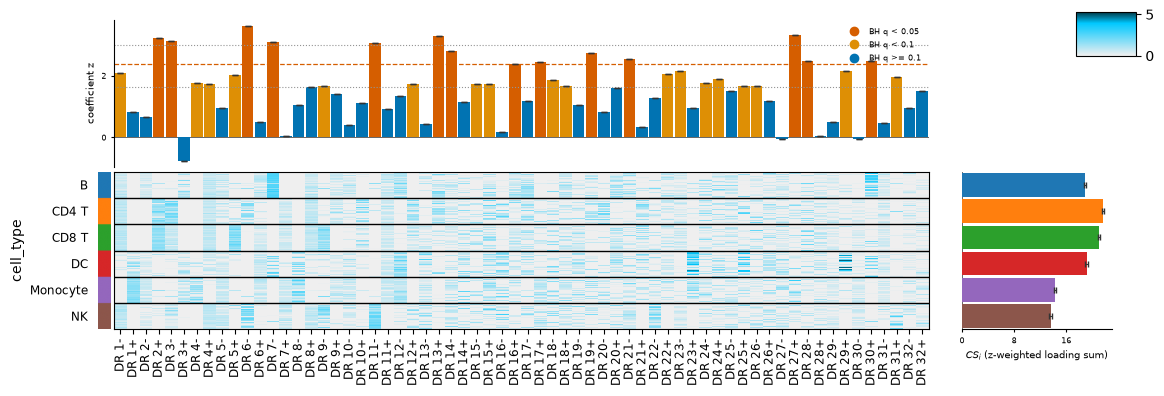

In [25]:
fig, _ = latent_heatmap(
    embed_scored, "cell_type",
    heritability=signed["Coefficient_z-score"], heritability_se=signed["Coefficient_std_error"],
    heritability_q=signed["fdr_q"], cell_scores=embed.obs["score"], cell_score_label=scores.label,
)
fig;

`cell_score_agg="sum"` instead of the default `"mean"` shows each group's raw,
non-normalised total instead of its per-cell average -- "non-normalised cell weights":
a large, modestly-scoring group can outweigh a small, high-scoring one here, the
opposite emphasis from the per-cell average above.

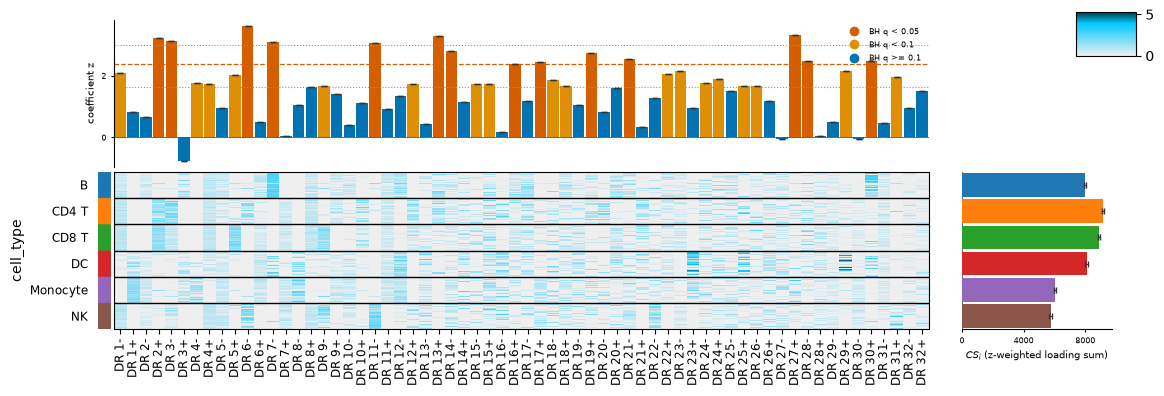

In [26]:
fig, _ = latent_heatmap(
    embed_scored, "cell_type",
    heritability=signed["Coefficient_z-score"], heritability_se=signed["Coefficient_std_error"],
    heritability_q=signed["fdr_q"], cell_scores=embed.obs["score"], cell_score_label=scores.label,
    cell_score_agg="sum",
)
fig;

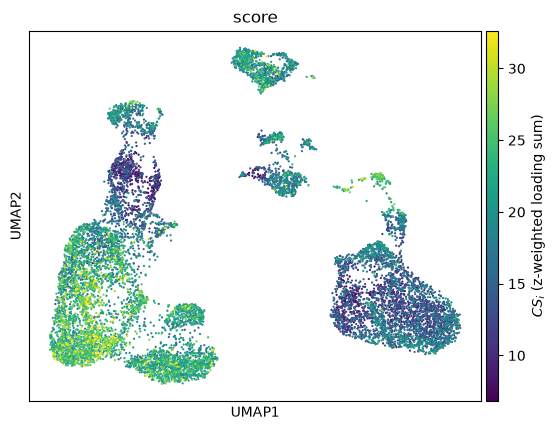

In [27]:
# A continuous embedding scatter is a scanpy call too -- vmin/vmax as scanpy's
# own percentile strings, matching scads_drvi.pl.color.ROBUST_LIMITS.
fig = sc.pl.embedding(
    embed, basis="umap", color="score", vmin="p1", vmax="p99.5",
    show=False, return_fig=True,
)
fig.axes[-1].set_ylabel(scores.label)
fig;

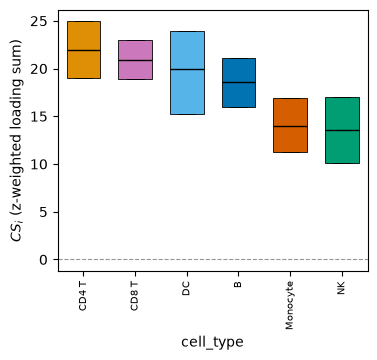

In [28]:
from scads_drvi.pl.enrichment import score_by_group
from scads_drvi.pl.frugal import box_stats

box_stats_frame = box_stats(cells["score"], cells["cell_type"].astype(str), min_n=10)
fig, _ = score_by_group(
    box_stats_frame, group_label="cell_type", value_label=scores.label, null=scores.null,
)
fig;

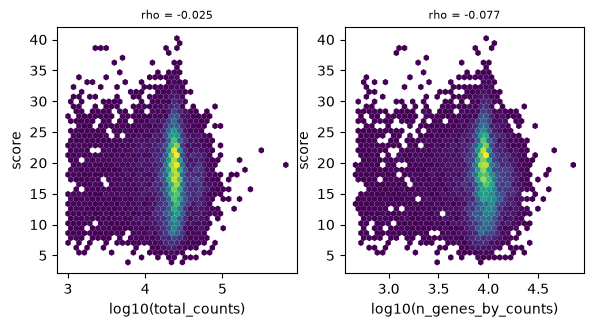

In [29]:
from scads_drvi.pl.enrichment import covariate_audit

# Does the score itself just track sequencing depth?
fig, _ = covariate_audit(
    cells, value="score", covariates=["total_counts", "n_genes_by_counts"],
    log_x=["total_counts", "n_genes_by_counts"],
)
fig;

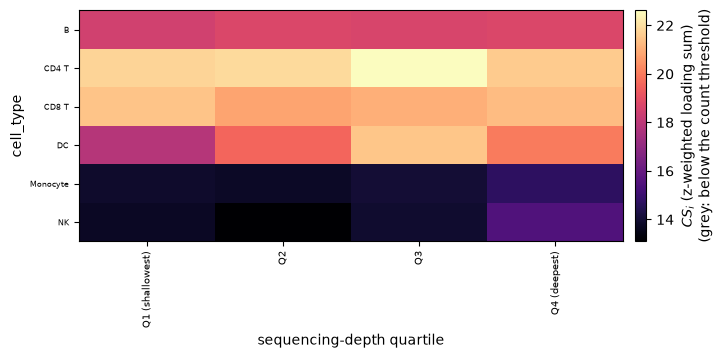

In [30]:
from scads_drvi.pl.enrichment import grouped_landscape
from scads_drvi.scores.aggregate import group_matrix

# A second, real grouping derived from the real per-cell depth -- not a second
# categorical obs column this dataset happens to carry.
cells["depth_quartile"] = pd.qcut(
    cells["total_counts"], 4, labels=["Q1 (shallowest)", "Q2", "Q3", "Q4 (deepest)"]
)
means, counts = group_matrix(
    scores.values, cells, index="cell_type", columns="depth_quartile", min_cells=10,
)
fig, _ = grouped_landscape(
    means, counts, row_label="cell_type", column_label="sequencing-depth quartile",
    value_label=scores.label,
)
fig;

## Where DRVI's own tools still take over

Every `pl.*` figure this package draws has been shown above: `latent_umap_grid` (a per-dimension embedding grid; a plain categorical or continuous embedding scatter is just `sc.pl.embedding` directly -- see above), `factor_correlation`/`factor_distributions`/`covariate_association`/`latent_dimension_stats`/`latent_heatmap` (factor diagnostics -- `latent_heatmap` itself optionally draws a per-dimension heritability bar above it and a per-group cell-score bar to its right, both with error bars, rather than a second `latent_heatmap_with_heritability`-style function), and `heritability_landscape`/`covariate_audit`/`score_by_group`/`grouped_landscape` (enrichment and scores) -- `latent_umap_grid`/`latent_dimension_stats`/`latent_heatmap` ported to match DRVI's own colours and mechanics exactly, wrapping `scanpy.pl.embedding` directly where an embedding is involved, needing no `drvi-py` install. (`trait_concordance` is the one figure not shown against real data here -- it compares two independently-run traits, and this tutorial only runs one.)

`latent_umap_grid` and `latent_heatmap` both default to `directional=True` -- every factor interpretability plot in this package shows split factors (each dimension's own +/- columns or panels) unless told not to (`directional=False`). `latent_heatmap`'s `cell_score_agg` also takes `"sum"` alongside the default `"mean"`/`"median"`, for a group's raw, non-normalised total rather than its per-cell average -- both shown in Section 4 above.

What genuinely still has no in-house equivalent is DRVI's own model-side interpretability: the model's `get_effect_of_splits_within_distribution`/`_out_of_distribution` (used above to rank each factor's top peaks) and `calculate_interpretability_scores`. `scads-drvi` wraps none of these a second time -- see the [DRVI docs](https://drvi.readthedocs.io/).